# Plot Figure 3B: Fitted concentration profiles

Plots fitted concentration profiles of HQNO and RHL.

Provided for completeness only, full code containing model fitting and parameter inference is provided in complimentary [Github Repository](https://github.com/simonvanvliet/SpatialToleranceModel) 

In [5]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json
import sympy as sp
import sys
sys.path.append(str(Path.cwd().parent / '0_plot_functions'))


def solve_symbolic_reaction_diffusion():
    """
    Solve the reaction-diffusion system symbolically for a 3-region domain.

    Domain:
    - Producer [0, L]: source S,   R_I   = -S/(2D)*x² + A*x
    - Gap [L, L+d]:   passive,     R_II  = C1*x + C2
    - Consumer [L+d, 2L+d]: sink,  R_III = M*sinh(k*(2L+d-x)),  k = sqrt(up/D)

    BCs: R(0)=0, R(2L+d)=0, continuity and width-weighted flux at interfaces.

    Returns dict of symbolic constants {A, C1, C2, M}.
    """
    L, d, D, S, up, W, W_gap, x = sp.symbols('L d D S up W W_gap x', positive=True)
    k = sp.sqrt(up / D)
    A_sym, C1_sym, C2_sym, M_sym = sp.symbols('A C1 C2 M')

    R_I   = -S/(2*D)*x**2 + A_sym*x
    R_II  = C1_sym*x + C2_sym
    R_III = M_sym*sp.sinh(k*(2*L + d - x))
    R_Ip, R_IIp, R_IIIp = sp.diff(R_I, x), sp.diff(R_II, x), sp.diff(R_III, x)

    eqs = [
        sp.Eq(R_I.subs(x, 0), 0),
        sp.Eq(R_III.subs(x, 2*L + d), 0),
        sp.Eq(R_I.subs(x, L), R_II.subs(x, L)),
        sp.Eq(W * R_Ip.subs(x, L), W_gap * R_IIp.subs(x, L)),
        sp.Eq(R_II.subs(x, L + d), R_III.subs(x, L + d)),
        sp.Eq(W_gap * R_IIp.subs(x, L + d), W * R_IIIp.subs(x, L + d)),
    ]
    return sp.solve(eqs, (A_sym, C1_sym, C2_sym, M_sym), dict=True)[0]


def conc_curve(solution_expr, L_val, d_val, W_val, W_gap_val, D_val, S_val, up_val, x_vals):
    """Evaluate steady-state concentration profile R(x) at x_vals."""
    A_sym, C1_sym, C2_sym, M_sym = sp.symbols('A C1 C2 M')
    L, d, D, S, up, W, W_gap = sp.symbols('L d D S up W W_gap', positive=True)
    num = {L: L_val, d: d_val, W: W_val, W_gap: W_gap_val, D: D_val, S: S_val, up: up_val}
    A_val  = float(solution_expr[A_sym].subs(num))
    C1_val = float(solution_expr[C1_sym].subs(num))
    C2_val = float(solution_expr[C2_sym].subs(num))
    M_val  = float(solution_expr[M_sym].subs(num))
    k_val  = float(sp.sqrt(up_val / D_val))

    x_arr = np.asarray(x_vals, dtype=float)
    out = np.empty_like(x_arr)
    m1 = x_arr < L_val
    m2 = (x_arr >= L_val) & (x_arr < L_val + d_val)
    m3 = ~(m1 | m2)
    out[m1] = -S_val/(2*D_val) * x_arr[m1]**2 + A_val * x_arr[m1]
    out[m2] = C1_val * x_arr[m2] + C2_val
    out[m3] = M_val * np.sinh(k_val * (2*L_val + d_val - x_arr[m3]))
    return out

# ----------------------------------------------------------
# Helper to solve a single species on the 3-region domain
# Producer [0, L] with source S; Gap [L, L+d] passive; Consumer [L+d, 2L+d] sink C
# Width-weighted flux continuity at interfaces is enforced.
# Returns numeric R(x), dR/dx(x), flux(x) and fitted constants.
# ----------------------------------------------------------
def solve_symbolic_reaction_diffusion():
    """
    Solve the reaction-diffusion system symbolically for a 3-region domain.
    
    Returns a dictionary containing the symbolic solution for the four integration
    constants (A, C1, C2, M) in terms of the system parameters (L, d, D, S, C, W, W_gap).
    
    The domain consists of:
    - Producer region [0, L]: source term S, solution form R_I = -S/(2D)*x^2 + A*x
    - Gap region [L, L+d]: passive diffusion, solution form R_II = C1*x + C2
    - Consumer region [L+d, 2L+d]: sink term up, solution form R_III = M*sinh(k*(2L+d-x)), where k = sqrt(up/D)
    
    Boundary conditions:
    - R(0) = 0 (Dirichlet at left boundary)
    - R(2L+d) = 0 (Dirichlet at right boundary)
    - Continuity of concentration at interfaces (x=L and x=L+d)
    - Width-weighted flux continuity at interfaces
    
    Returns:
        dict: Symbolic solution with keys A_sym, C1_sym, C2_sym, M_sym
    """
    # Symbolic setup
    L, d, D, S, up, W, W_gap, x = sp.symbols('L d D S up W W_gap x', positive=True)
    k = sp.sqrt(up / D)

    A_sym, C1_sym, C2_sym, M_sym = sp.symbols('A C1 C2 M')

    # Piecewise solution forms:
    R_I   = -S/(2*D)*x**2 + A_sym*x                         # Producer with source S
    R_II  = C1_sym*x + C2_sym                               # Gap (pure diffusion)
    R_III = M_sym*sp.sinh(k*(2*L + d - x))                  # Consumer with sink C

    # Derivatives
    R_Ip, R_IIp, R_IIIp = sp.diff(R_I, x), sp.diff(R_II, x), sp.diff(R_III, x)

    # BCs + width-weighted flux continuity
    eqs = [
        sp.Eq(R_I.subs(x, 0), 0),                                # R(0) = 0
        sp.Eq(R_III.subs(x, 2*L + d), 0),                        # R(2L+d) = 0
        sp.Eq(R_I.subs(x, L), R_II.subs(x, L)),                  # Continuity at x=L
        sp.Eq(W * R_Ip.subs(x, L), W_gap * R_IIp.subs(x, L)),    # Flux continuity at x=L
        sp.Eq(R_II.subs(x, L + d), R_III.subs(x, L + d)),        # Continuity at x=L+d
        sp.Eq(W_gap * R_IIp.subs(x, L + d), W * R_IIIp.subs(x, L + d)) # Flux continuity at x=L+d
    ]

    return sp.solve(eqs, (A_sym, C1_sym, C2_sym, M_sym), dict=True)[0]

def conc_curve(solution_expr, L_val, d_val, W_val, W_gap_val, D_val, S_val, up_val, x_vals):
    """
    Compute steady-state concentration profile R(x) on a 3-region domain using the
    symbolic solution constants and specified parameter values.

    Args:
        solution_expr (dict): Symbolic expressions for A, C1, C2, M from solve_symbolic_reaction_diffusion.
        L_val (float): Length of producer/consumer regions.
        d_val (float): Length of the gap region.
        W_val (float): Width of producer/consumer regions.
        W_gap_val (float): Width of the gap region.
        D_val (float): Diffusion coefficient.
        S_val (float): Source term in the producer region.
        up_val (float): Uptake (sink) rate in the consumer region.
        x_vals (array-like): Positions at which to evaluate R(x).

    Returns:
        np.ndarray: Concentration values R(x) evaluated at x_vals.
    """
    # set up symbols and substitute parameter values
    A_sym, C1_sym, C2_sym, M_sym = sp.symbols('A C1 C2 M')
    L, d, D, S, up, W, W_gap = sp.symbols('L d D S up W W_gap', positive=True)
    num = {L: L_val, d: d_val, W: W_val, W_gap: W_gap_val, D: D_val, S: S_val, up: up_val}
    A_val  = float(solution_expr[A_sym].subs(num))
    C1_val = float(solution_expr[C1_sym].subs(num))
    C2_val = float(solution_expr[C2_sym].subs(num))
    M_val  = float(solution_expr[M_sym].subs(num))
    k_val  = float(sp.sqrt(up_val / D_val))

    x_arr = np.asarray(x_vals, dtype=float)
    out = np.empty_like(x_arr)

    # Define masks for the three regions
    m1 = x_arr < L_val
    m2 = (x_arr >= L_val) & (x_arr < L_val + d_val)
    m3 = ~(m1 | m2)

    # Compute concentration in each region
    out[m1] = -S_val/(2 * D_val) * x_arr[m1]**2 + A_val * x_arr[m1]
    out[m2] = C1_val * x_arr[m2] + C2_val
    out[m3] = M_val * np.sinh(k_val * (2 * L_val + d_val - x_arr[m3]))
    return out



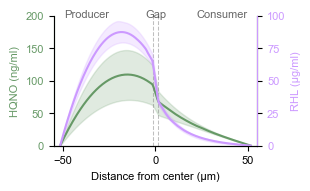

In [6]:
# ===========================================================
# Load parameters 
# ===========================================================

# Load model parameters
parameter_CSV = Path.cwd().parent / 'model_fit_parameters' / 'full_model_parameters.csv'
df = pd.read_csv(parameter_CSV)
cols = ['uptake rate', 'production rate', 'Deff']

# get fitted rates
df_h = df[df['molecule'] == 'HQNO'][cols]
df_r = df[df['molecule'] == 'RHL'][cols]

# diffusion coefficients
D_H = df_h['Deff'].median()  # µm²/s - effective diffusion coefficient HQNO in chamber, from fitted model
D_R = df_r['Deff'].median()  # µm²/s - effective diffusion coefficient RHL in chamber, from fitted model

# fixed parameters
L = 50.0         # µm, chamber length
d = 3.0          # µm, gap length
W = 50.0         # µm, chamber width
W_gap = 12.5     # µm, gap width (0.25 * W)]

# --- Predict concentration profiles---
y_fit = np.linspace(0, 2*L + d, 181)
y_from_center = y_fit - (L + d/2)

# Solve symbolic reaction-diffusion system
analytical_solution = solve_symbolic_reaction_diffusion()

# Calculate concentration profiles using exhaustive empirical sampling of replicates to estimate variability
pred_conc_H = []
for i in range(len(df_h.index)):
    S_H = df_h["production rate"].iloc[i]
    up_H = df_h["uptake rate"].iloc[i]
    conc_H = conc_curve(analytical_solution, L, d, W, W_gap, D_H, S_H, up_H, y_fit)
    pred_conc_H.append({'replicate': i, 'y_um': y_from_center, 'concentration': conc_H})

pred_conc_R = []
for i in range(len(df_r.index)):
    S_R = df_r["production rate"].iloc[i]
    up_R = df_r["uptake rate"].iloc[i]
    conc_R = conc_curve(analytical_solution, L, d, W, W_gap, D_R, S_R, up_R, y_fit)
    pred_conc_R.append({'replicate': i, 'y_um': y_from_center, 'concentration': conc_R})

df_pred_conc_H = pd.DataFrame(pred_conc_H).explode(['y_um', 'concentration'])
df_pred_conc_R = pd.DataFrame(pred_conc_R).explode(['y_um', 'concentration'])

# ——— figure style ———
final_width_in  = 8 / 2.54
final_height_in = 5 / 2.54
font_size = 8
plt.rcParams.update({
    'font.size': font_size,
    'font.family': 'Arial',
    'axes.labelsize': font_size,
    'axes.titlesize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

hqno_color = '#669966'
rhl_color  = '#cc99ff'

fig, ax1 = plt.subplots(figsize=(final_width_in, final_height_in))
ax2 = ax1.twinx()

# Plot HQNO (left axis) and RHL (right axis)
for ax, df_pred, color, ylabel, ylim, yticks in [
    (ax1, df_pred_conc_H, hqno_color, 'HQNO (ng/ml)', (0, 200), np.linspace(0, 200, 5)),
    (ax2, df_pred_conc_R, rhl_color,  'RHL (µg/ml)',  (0, 100), np.linspace(0, 100, 5)),
]:
    perc = df_pred.groupby('y_um')['concentration'].agg([
        ('lower',  lambda x: np.percentile(x.dropna(), 25)),
        ('median', lambda x: np.percentile(x.dropna(), 50)),
        ('upper',  lambda x: np.percentile(x.dropna(), 75)),
    ]).reset_index().sort_values('y_um')
    ax.fill_between(perc['y_um'], perc['lower'], perc['upper'], alpha=0.2, color=color)
    ax.plot(perc['y_um'], perc['median'], '-', lw=1.5, color=color)
    ax.set_ylabel(ylabel, color=color, fontsize=font_size)
    ax.tick_params(axis='y', labelcolor=color, labelsize=font_size)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)

ax1.set_xlabel("Distance from center (µm)", fontsize=font_size)
ax1.set_xlim(-55, 55)
ax1.set_xticks([-50, 0, 50])
ax1.tick_params(axis='x', labelsize=font_size)
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_color(hqno_color)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color(rhl_color)

ax1.axvline(x=-d/2, linestyle='--', color='gray', linewidth=0.75, alpha=0.5)
ax1.axvline(x= d/2, linestyle='--', color='gray', linewidth=0.75, alpha=0.5)

ax1.text(0.05, 1.05, 'Producer',  transform=ax1.transAxes, ha='left',   va='top', fontsize=font_size, alpha=0.6)
ax1.text(0.5,  1.05, 'Gap',       transform=ax1.transAxes, ha='center', va='top', fontsize=font_size, alpha=0.6)
ax1.text(0.95, 1.05, 'Consumer',  transform=ax1.transAxes, ha='right',  va='top', fontsize=font_size, alpha=0.6)

plt.tight_layout()
